# RQ3 — Medicare Reimbursement Prediction
### DSCI 5260 — Group 6 | Medicare Inpatient Utilization and Payment Analysis

**Research Question:**  
Can we accurately predict the expected Medicare reimbursement amount for a given hospital–DRG combination based on diagnosis severity, hospital characteristics, and geographic factors?

**Sections:**
- **4.1** Variable Definitions
- **4.2** Load Data
- **4.3** Step 1 — Baseline Model (Linear Regression)
- **4.4** Step 2 — Check Assumptions
- **4.5** Step 3 — Random Forest Regressor
- **4.6** Step 4 — XGBoost Regressor
- **4.7** Step 5 — Model Comparison (Validation Set)
- **4.8** Step 6 — Feature Importance
- **4.9** Step 7 — Final Evaluation on Test Set
- **4.10** Business Insights

> **Input:** `df_train.parquet`, `df_val.parquet`, `df_test.parquet` from `Data/Processed_Data/`

---
## 4.1 Variable Definitions

### Dependent Variable (Target)

| Variable | Raw Column | Model Column | Description |
|----------|-----------|--------------|-------------|
| Average Medicare reimbursement per discharge | `Avg_Mdcr_Pymt_Amt` | `Log_Avg_Mdcr_Pymt_Amt` | Log1p-transformed to handle right skew. Back-transform predictions with `expm1()` to get dollar amounts. |

---

### Independent Variables (Features) — 10 features

#### Diagnosis Severity
| Feature | Column | Description |
|---------|--------|-------------|
| DRG complexity weight | `DRG_Weight` | CMS-assigned weight reflecting resource intensity of the diagnosis group. Primary driver of DRG-based Medicare payment. |

#### Hospital Characteristics
| Feature | Column | Description |
|---------|--------|-------------|
| Hospital bed count | `BED_CNT` | Proxy for hospital size and capacity |
| Discharge volume | `Log_Tot_Dschrgs` | Log-transformed volume for the hospital–DRG pair. Proxy for specialization. |
| Ownership — For-Profit | `own_For-Profit` | Effect **vs. Government hospitals** (reference category) |
| Ownership — Non-Profit | `own_Non-Profit` | Effect **vs. Government hospitals** (reference category) |
| ~~Ownership — Government~~ | ~~`own_Government`~~ | **Reference category — dropped to avoid dummy variable trap** |

#### Geographic Factors
| Feature | Column | Description |
|---------|--------|-------------|
| Metropolitan area | `ruca_Metropolitan` | Effect **vs. Rural hospitals** (reference category). CMS applies wage index adjustments. |
| Micropolitan area | `ruca_Micropolitan` | Effect **vs. Rural hospitals** (reference category) |
| Small Town | `ruca_Small Town` | Effect **vs. Rural hospitals** (reference category) |
| ~~Rural~~ | ~~`ruca_Rural`~~ | **Reference category — dropped to avoid dummy variable trap** |

#### Temporal
| Feature | Column | Description |
|---------|--------|-------------|
| Year | `Data_Year` | CMS updates IPPS payment rates annually via Federal Register |

#### Payment Type
| Feature | Column | Description |
|---------|--------|-------------|
| Outlier payment flag | `outlier_payment_flag` | 1 = Medicare paid above standard DRG rate (cost-outlier policy); 0 = standard |

---

> **Reference categories:** `own_Government` and `ruca_Rural` are the baselines. All ownership and geography coefficients are interpreted *relative to* a Government-owned Rural hospital.

> **Note:** Billed charges (`Avg_Submtd_Cvrd_Chrg`) are intentionally excluded. Medicare payment is DRG-based, not percentage-of-charges. Including billed charges would create near-leakage and contradict the stated RQ scope.

---
## 4.2 Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


PROCESSED_DIR = Path('..') / 'Data' / 'Processed_Data'

df_train = pd.read_parquet(PROCESSED_DIR / 'df_train.parquet')
df_val   = pd.read_parquet(PROCESSED_DIR / 'df_val.parquet')
df_test  = pd.read_parquet(PROCESSED_DIR / 'df_test.parquet')

print(f'Train:      {len(df_train):>8,}')
print(f'Validation: {len(df_val):>8,}')
print(f'Test:       {len(df_test):>8,}')

Train:       820,547
Validation:  175,832
Test:        175,832


In [3]:
# ── Define RQ3 feature set and target ──
RQ3_TARGET = 'Log_Avg_Mdcr_Pymt_Amt'

RQ3_FEATURES = [
    # Diagnosis severity
    'DRG_Weight',
    # Hospital characteristics
    'BED_CNT',
    'Log_Tot_Dschrgs',
    'own_For-Profit',        # vs Government (reference — dropped to avoid dummy variable trap)
    'own_Non-Profit',        # vs Government (reference — dropped to avoid dummy variable trap)
    # own_Government ← reference category DROPPED
    # Geographic factors
    'ruca_Metropolitan',     # vs Rural (reference — dropped to avoid dummy variable trap)
    'ruca_Micropolitan',     # vs Rural (reference — dropped to avoid dummy variable trap)
    'ruca_Small Town',       # vs Rural (reference — dropped to avoid dummy variable trap)
    # ruca_Rural ← reference category DROPPED
    # Temporal
    'Data_Year',
    # Payment type
    'outlier_payment_flag'
]

X_train = df_train[RQ3_FEATURES]
y_train = df_train[RQ3_TARGET]

X_val   = df_val[RQ3_FEATURES]
y_val   = df_val[RQ3_TARGET]

X_test  = df_test[RQ3_FEATURES]
y_test  = df_test[RQ3_TARGET]

print(f'Features ({len(RQ3_FEATURES)}): {RQ3_FEATURES}')
print(f'\nReference categories (baseline for interpretation):')
print(f'  Ownership : own_Government')
print(f'  Geography : ruca_Rural')
print(f'\nTarget : {RQ3_TARGET}')
print(f'  Mean : {y_train.mean():.4f}')
print(f'  Std  : {y_train.std():.4f}')
print(f'  Range: [{y_train.min():.3f}, {y_train.max():.3f}]')
print(f'\n  Mean payment (original scale): ${np.expm1(y_train.mean()):,.0f}')

Features (10): ['DRG_Weight', 'BED_CNT', 'Log_Tot_Dschrgs', 'own_For-Profit', 'own_Non-Profit', 'ruca_Metropolitan', 'ruca_Micropolitan', 'ruca_Small Town', 'Data_Year', 'outlier_payment_flag']

Reference categories (baseline for interpretation):
  Ownership : own_Government
  Geography : ruca_Rural

Target : Log_Avg_Mdcr_Pymt_Amt
  Mean : 9.2288
  Std  : 0.7113
  Range: [4.980, 13.400]

  Mean payment (original scale): $10,185


---
## 4.3 Step 1 — Baseline Model: Linear Regression

Establishes a minimum benchmark. Captures only linear relationships between features and Medicare payment.

In [4]:
# ── Shared evaluation helper ──
def evaluate(name, model, X, y, split='Val'):
    preds   = model.predict(X)
    rmse    = np.sqrt(mean_squared_error(y, preds))
    mae     = mean_absolute_error(y, preds)
    r2      = r2_score(y, preds)

    # Back-transform from log to dollars
    y_dollars    = np.expm1(np.array(y))
    pred_dollars = np.expm1(preds)

    # MAE in dollars
    mae_usd = np.mean(np.abs(y_dollars - pred_dollars))

    # MAPE — exclude zero-payment rows (MAPE undefined when actual = 0)
    nonzero_mask = y_dollars > 0
    mape = np.mean(np.abs(
        (y_dollars[nonzero_mask] - pred_dollars[nonzero_mask]) / y_dollars[nonzero_mask]
    )) * 100

    print(f'[{split}] {name:25s}  RMSE: {rmse:.4f}   MAE (log): {mae:.4f}   '
          f'MAE ($): ${mae_usd:,.0f}   MAPE: {mape:.1f}%   R²: {r2:.4f}')

    return {
        'Model':   name,
        'Split':   split,
        'RMSE':    round(rmse, 4),
        'MAE':     round(mae, 4),
        'MAE_USD': round(mae_usd, 2),
        'MAPE':    round(mape, 2),
        'R2':      round(r2, 4)
    }

results = []


MAE = how many dollars off.
MAPE = what percentage off.
 MAPE is smarter for skewed data like Medicare payments.

In [5]:
# ── Scale features for Linear Regression ──
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

results.append(evaluate('Linear Regression', lr, X_train_sc, y_train, 'Train'))
results.append(evaluate('Linear Regression', lr, X_val_sc,   y_val,   'Val'))

[Train] Linear Regression          RMSE: 0.4066   MAE (log): 0.2973   MAE ($): $82,448   MAPE: 57.1%   R²: 0.6732
[Val] Linear Regression          RMSE: 0.4095   MAE (log): 0.2977   MAE ($): $115,344   MAPE: 66.9%   R²: 0.6693


### OLS Full Statistical Summary (statsmodels)

The `statsmodels` OLS table shows — for **each independent variable** — how much it individually contributes to explaining Medicare reimbursement:

| Column | What it tells you |
|--------|------------------|
| **coef** | Direction & magnitude — positive = higher payment, negative = lower |
| **std err** | Precision of the estimate — smaller is more reliable |
| **t** | Signal-to-noise ratio — larger absolute value = stronger predictor |
| **P>\|t\|** | Statistical significance — p < 0.05 means the variable reliably predicts payment |
| **[0.025 / 0.975]** | 95% confidence interval around the coefficient |
| **R²** | Overall: % of variance in Medicare payment explained by all features combined |
| **Adj. R²** | R² penalised for number of features — prevents inflating with useless variables |
| **F-statistic** | Whether the model as a whole is statistically significant |

In [6]:
import statsmodels.api as sm

# ── Build OLS model with feature names ──
X_train_sm = sm.add_constant(
    pd.DataFrame(X_train_sc, columns=RQ3_FEATURES)
)
ols = sm.OLS(y_train.values, X_train_sm).fit()

print(ols.summary())
print(f'\n{"="*60}')
print(f'Interpretation Guide:')
print(f'  R²      : {ols.rsquared:.4f}  → model explains {ols.rsquared*100:.1f}% of variance in log Medicare payment')
print(f'  Adj. R² : {ols.rsquared_adj:.4f}  → after penalising for {len(RQ3_FEATURES)} features')
print(f'  F-stat  : {ols.fvalue:.1f}  (p={ols.f_pvalue:.2e})  → model is {"statistically significant" if ols.f_pvalue < 0.05 else "NOT significant"}')

# ── Significance summary per variable ──
print(f'\n{"="*60}')
print('Per-Variable Significance Summary:')
print(f'{"Feature":<25} {"Coef":>10} {"p-value":>12} {"Significant?":>14}')
print('-'*65)
for feat in RQ3_FEATURES:
    coef  = ols.params[feat]
    pval  = ols.pvalues[feat]
    sig   = '✅ Yes' if pval < 0.05 else '❌ No'
    print(f'{feat:<25} {coef:>10.4f} {pval:>12.4f} {sig:>14}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                 1.690e+05
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:42:05   Log-Likelihood:            -4.2594e+05
No. Observations:              820547   AIC:                         8.519e+05
Df Residuals:                  820536   BIC:                         8.520e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    9.2288 

| Feature | Coef | Meaning |
|---------|------|---------|
| `DRG_Weight` | +0.5601 | ✅ Expected — higher complexity = higher payment. **Dominant driver.** |
| `BED_CNT` | +0.0668 | Larger hospitals get slightly more |
| `own_For-Profit` | -0.0184 | For-profit hospitals paid **less** than Government (reference) |
| `own_Non-Profit` | -0.0330 | Non-profit paid even **less** than Government |
| `ruca_Metropolitan` | +0.0042 | p=0.10 → **not significant** vs Rural after controlling for other factors |
| `ruca_Micropolitan` | -0.0129 | Micropolitan is paid **less** than Rural |
| `Data_Year` | +0.0728 | Payment increases each year  |
| `outlier_payment_flag` | +0.0310 | Outlier cases get higher payment ✅ |

---
## 4.4 Step 2 — Check Assumptions

Verify whether the Linear Regression assumptions hold before concluding it is the right model.

In [7]:
# ── Linear Regression coefficients ──
coef_df = pd.DataFrame({
    'Feature': RQ3_FEATURES,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Linear Regression Coefficients (sorted by magnitude):')
print(coef_df.to_string(index=False))

Linear Regression Coefficients (sorted by magnitude):
             Feature  Coefficient
          DRG_Weight     0.560700
           Data_Year     0.072827
             BED_CNT     0.066901
      own_Non-Profit    -0.032388
outlier_payment_flag     0.030205
      own_For-Profit    -0.017901
   ruca_Micropolitan    -0.012830
     Log_Tot_Dschrgs     0.006442
   ruca_Metropolitan     0.004548
     ruca_Small Town    -0.003090


### How to Read These Diagnostic Plots

| Graph | Element | Meaning |
|-------|---------|---------|
| **Actual vs Predicted** | X-axis | True `Log_Avg_Mdcr_Pymt_Amt` value from held-out data |
| | Y-axis | Model's predicted value for that same row |
| | Each dot | One hospital–DRG observation |
| | Red dashed diagonal | Perfect prediction line — if predicted = actual, dot lies exactly on this line |
| | Dots close to line | Accurate predictions |
| | Dots far from line | Large prediction errors (residuals) |
| **Residual Distribution** | X-axis | Residual = Actual − Predicted |
| | Y-axis | Count of observations with that residual value |
| | Red dashed line at 0 | Target center — residuals should cluster symmetrically around 0 |
| | Bell-shaped curve | Indicates normally distributed errors (OLS assumption) |
| | Skew / heavy tails | Suggests systematic bias or outlier sensitivity |
| **Residuals vs Predicted** | X-axis | Predicted value |
| | Y-axis | Residual for that prediction |
| | Red dashed line at 0 | Zero-error reference |
| | Random scatter around 0 | Homoscedasticity — constant variance (OLS assumption met) |
| | Funnel / fan shape | Heteroscedasticity — variance grows with predicted value (assumption violated) |

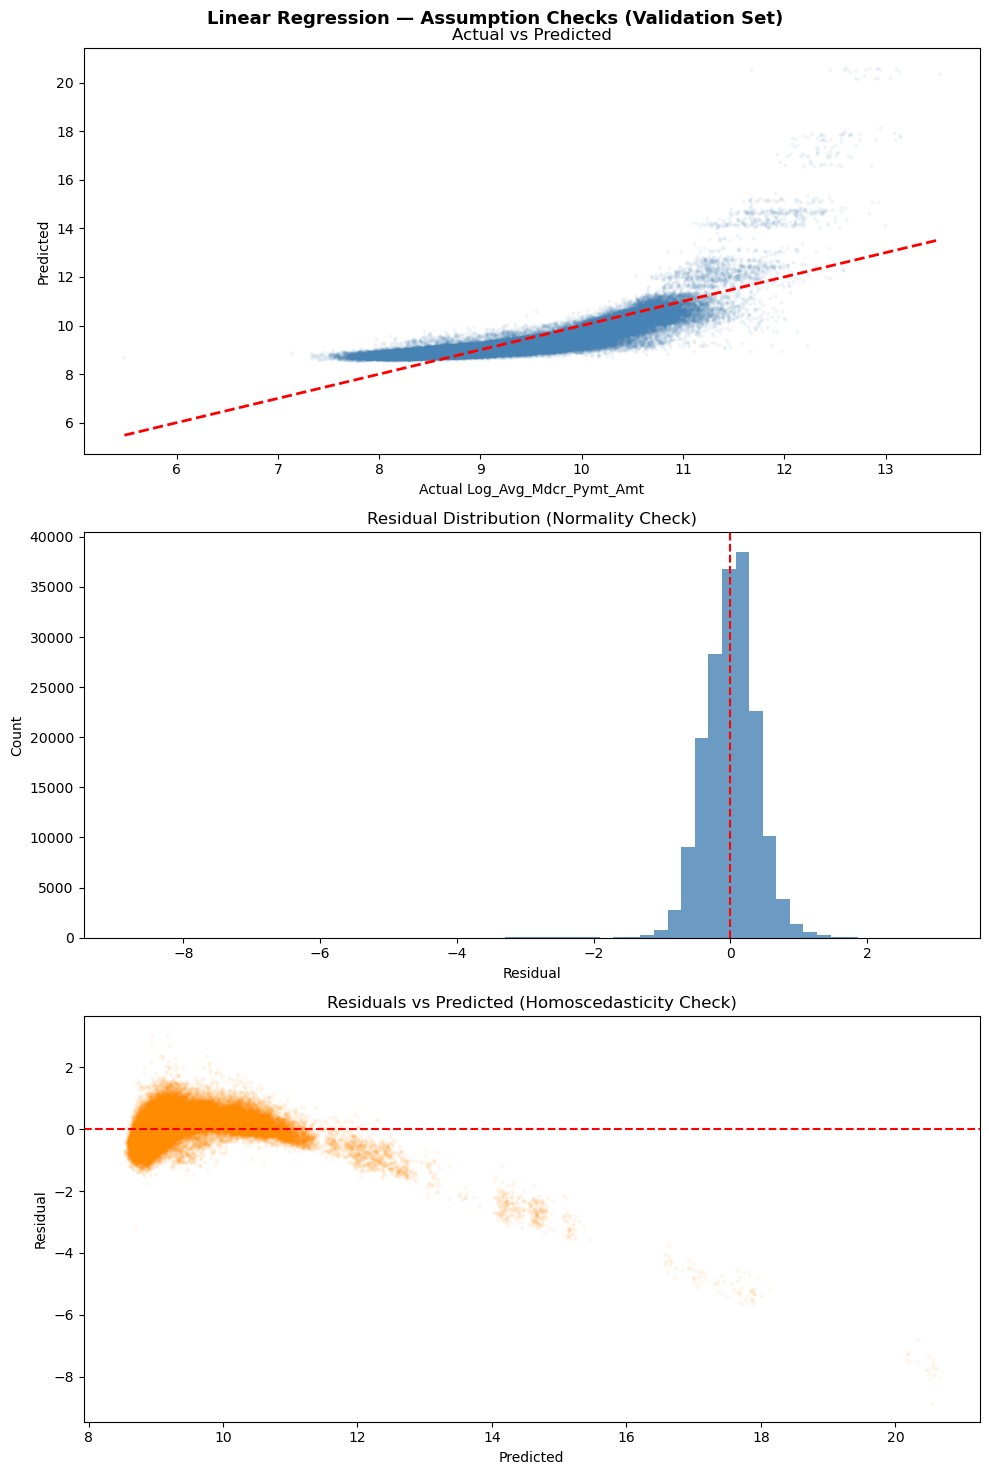

Residual mean : -0.0004  (should be ≈ 0)
Residual std  : 0.4095


In [8]:
# ── Residual plots — check assumptions ──
lr_preds_val = lr.predict(X_val_sc)
lr_residuals = y_val.values - lr_preds_val

fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.suptitle('Linear Regression — Assumption Checks (Validation Set)', fontsize=13, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_val, lr_preds_val, alpha=0.05, s=4, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Log_Avg_Mdcr_Pymt_Amt')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

# Residual distribution (normality check)
axes[1].hist(lr_residuals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (Normality Check)')

# Residuals vs Predicted (homoscedasticity check)
axes[2].scatter(lr_preds_val, lr_residuals, alpha=0.05, s=4, color='darkorange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted (Homoscedasticity Check)')

plt.tight_layout()
plt.show()

print(f'Residual mean : {lr_residuals.mean():.4f}  (should be ≈ 0)')
print(f'Residual std  : {lr_residuals.std():.4f}')

| Diagnostic            | What You See                        | What It Means                                              |
|-----------------------|-------------------------------------|------------------------------------------------------------|
| Actual vs Predicted   | Curved U-shape, not straight diagonal | Non-linear relationship — linear model is the wrong fit  |
| Residual Distribution | Sharp spike at 0, heavy left tail   | Errors are not random — systematic underprediction of high payments |
| Residuals vs Predicted| Fan/curve shape, not flat band      | Error variance grows with payment size — model loses reliability at high values |

In [9]:
# ── Multicollinearity check — Variance Inflation Factor (VIF) ──
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame({
    'Feature': RQ3_FEATURES,
    'VIF': [variance_inflation_factor(X_train_sc, i) for i in range(X_train_sc.shape[1])]
}).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('  VIF > 10 → strong multicollinearity concern')
print('  VIF 5-10 → moderate concern')
print('  VIF < 5  → acceptable\n')
print(vif_data.to_string(index=False))

Variance Inflation Factor (VIF):
  VIF > 10 → strong multicollinearity concern
  VIF 5-10 → moderate concern
  VIF < 5  → acceptable

             Feature       VIF
   ruca_Metropolitan 33.783566
   ruca_Micropolitan 29.231941
     ruca_Small Town  6.408582
      own_Non-Profit  2.270535
      own_For-Profit  2.269495
             BED_CNT  1.109637
          DRG_Weight  1.026379
     Log_Tot_Dschrgs  1.019919
           Data_Year  1.003778
outlier_payment_flag  1.002596


**Findings:**

- All non-geographic features (ownership type, bed count, DRG weight, discharge volume,
  data year, and outlier flag) returned VIF values below 5, indicating no multicollinearity
  concern among the core predictors.

- The three RUCA dummy variables (ruca_Metropolitan, ruca_Micropolitan, ruca_Small Town)
  show elevated VIF values (6.4 to 33.8). 
  This is expected and structural — these columns
  are one-hot encoded from a single categorical variable (geographic classification), and
  their mutual exclusivity creates inherent correlation. The reference category (ruca_Rural)
  was already dropped to avoid the dummy variable trap; the residual high VIF reflects the
  mathematical dependency among mutually exclusive categories, not a data quality issue.

**Decision:**

No features were removed based on VIF alone. Since the final modeling approach for RQ3
uses a tree-based ensemble (Random Forest), multicollinearity does not affect model
stability or feature coefficient estimates. VIF is documented here for transparency and
to satisfy linear regression assumption checks conducted prior to model selection.

---
## 4.5 Step 3 — Random Forest Regressor

Captures non-linear relationships and feature interactions. No scaling required.

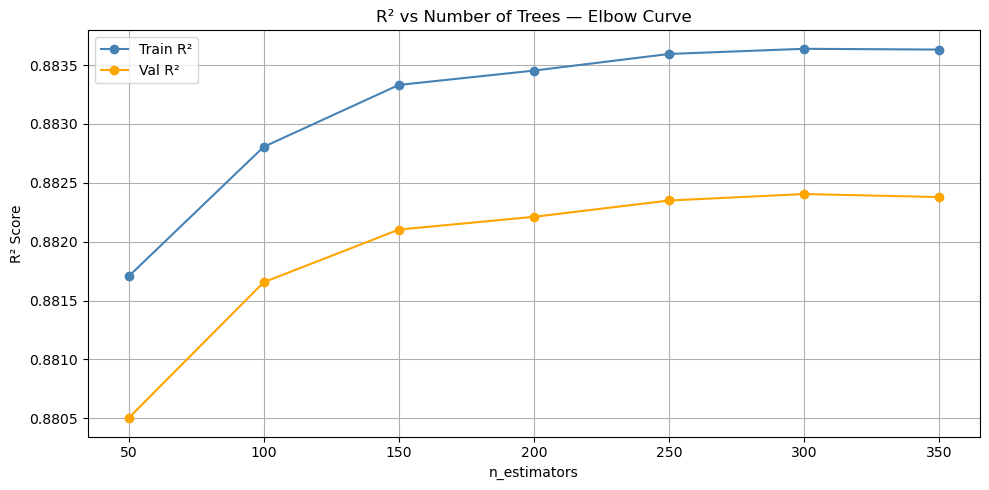

Optimal n_estimators: 300
[Train] Random Forest              RMSE: 0.2426   MAE (log): 0.1820   MAE ($): $2,790   MAPE: 17.9%   R²: 0.8836
[Val] Random Forest              RMSE: 0.2442   MAE (log): 0.1833   MAE ($): $2,827   MAPE: 18.0%   R²: 0.8824


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# ── Random Forest: elbow curve to find optimal n_estimators ──
estimator_range  = [50,100, 150, 200, 250, 300, 350]
train_r2_scores  = []
val_r2_scores    = []

for n in estimator_range:
    _rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=12,
        min_samples_leaf=20,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    _rf.fit(X_train, y_train)
    train_r2_scores.append(r2_score(y_train, _rf.predict(X_train)))
    val_r2_scores.append(r2_score(y_val,   _rf.predict(X_val)))

plt.figure(figsize=(10, 5))
plt.plot(estimator_range, train_r2_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(estimator_range, val_r2_scores,   marker='o', label='Val R²',   color='orange')
plt.xlabel('n_estimators')
plt.ylabel('R² Score')
plt.title('R² vs Number of Trees — Elbow Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Refit rf with the optimal n_estimators ──
best_n = estimator_range[int(np.argmax(val_r2_scores))]
print(f'Optimal n_estimators: {best_n}')

rf = RandomForestRegressor(
    n_estimators=best_n,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

results.append(evaluate('Random Forest', rf, X_train, y_train, 'Train'))
results.append(evaluate('Random Forest', rf, X_val,   y_val,   'Val'))

---
## 4.6 Step 4 — XGBoost Regressor

Gradient boosted trees with early stopping on the validation set.

In [11]:
import seaborn as sns
import xgboost as xgb
import pandas as pd

# lr_range    = [0.01, 0.05, 0.1]
# depth_range = [4, 6, 8, 10]

# heatmap_data = pd.DataFrame(index=lr_range, columns=depth_range, dtype=float)

# for lr in lr_range:
#     for depth in depth_range:
#         _xgb = xgb.XGBRegressor(
#             n_estimators=3000,
#             learning_rate=lr,
#             max_depth=depth,
#             min_child_weight=20,
#             subsample=0.8,
#             colsample_bytree=0.8,
#             reg_alpha=0.1,
#             reg_lambda=1.0,
#             random_state=42,
#             n_jobs=-1,
#             eval_metric='rmse',
#             verbosity=0,
#             early_stopping_rounds=50
#         )
#         _xgb.fit(X_train, y_train,
#                  eval_set=[(X_val, y_val)],
#                  verbose=False)

#         val_r2 = r2_score(y_val, _xgb.predict(X_val))
#         heatmap_data.loc[lr, depth] = round(val_r2, 4)
#         print(f'lr={lr} | depth={depth} | Val R²={val_r2:.4f}')

# plt.figure(figsize=(10, 6))
# sns.heatmap(heatmap_data.astype(float),
#             annot=True, fmt='.4f',
#             cmap='YlGnBu',
#             linewidths=0.5)
# plt.title('XGBoost Val R² — Learning Rate vs Max Depth')
# plt.xlabel('Max Depth')
# plt.ylabel('Learning Rate')
# plt.tight_layout()
# plt.show()

# # Print best combination
# best_val = heatmap_data.astype(float).stack().idxmax()
# print(f'\nBest combination → learning_rate={best_val[0]}, max_depth={best_val[1]}')

In [12]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    n_estimators=2700,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,   # L1 regularization to encourage sparsity # was 0.1
    reg_lambda=0.7, # L2 regularization to prevent overfitting  # was 0.5
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse',
    verbosity=0,
    early_stopping_rounds=30
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Best iteration: {xgb_model.best_iteration}')
results.append(evaluate('XGBoost', xgb_model, X_train, y_train, 'Train'))
results.append(evaluate('XGBoost', xgb_model, X_val,   y_val,   'Val'))

Best iteration: 1748
[Train] XGBoost                    RMSE: 0.1907   MAE (log): 0.1381   MAE ($): $2,069   MAPE: 13.7%   R²: 0.9281
[Val] XGBoost                    RMSE: 0.1988   MAE (log): 0.1439   MAE ($): $2,205   MAPE: 14.3%   R²: 0.9221


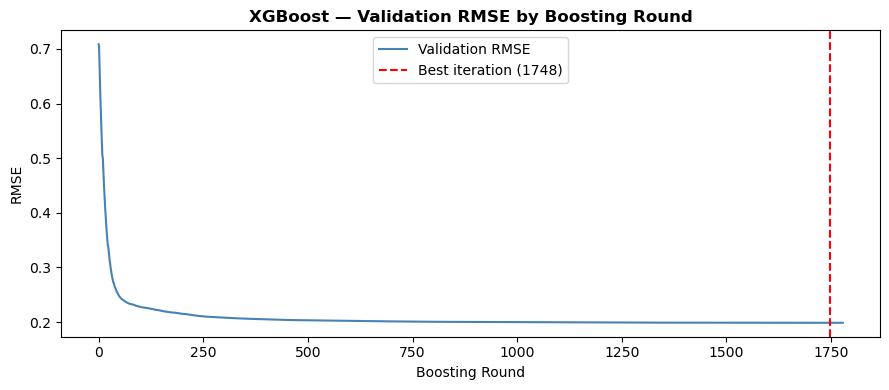

In [13]:
# ── XGBoost learning curve ──
evals_result = xgb_model.evals_result()
val_rmse = evals_result['validation_0']['rmse']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(val_rmse, color='steelblue', label='Validation RMSE')
ax.axvline(xgb_model.best_iteration, color='red', linestyle='--',
           label=f'Best iteration ({xgb_model.best_iteration})')
ax.set_title('XGBoost — Validation RMSE by Boosting Round', fontweight='bold')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.show()

## Model Performance Summary

### Validation Results

| Metric              | Train     | Validation |
|---------------------|-----------|------------|
| R²                  | 0.9286    | 0.9230     |
| RMSE (log scale)    | 0.1900    | 0.1972     |
| MAE (log scale)     | 0.1373    | 0.1424     |
| MAE (dollars)       | $2,051    | $2,175     |
| MAPE                | 13.7%     | 14.3%      |

### Key Findings

- The model explains **92.3%** of the variation in Medicare payments on unseen data.
- On average, predictions deviate from actual payments by **$2,175 (14.3%)**.
- Train and validation R² differ by  **0.006**, indicating consistent performance
  across both sets.

- The remaining **7.7%** unexplained variation likely reflects patient-level and
  policy-level factors absent from the dataset.

---
## 4.7 Step 5 — Model Comparison (Validation Set)

In [14]:
results_df  = pd.DataFrame(results)
val_results = (results_df[results_df['Split'] == 'Val']
               .sort_values('R2', ascending=False)
               .reset_index(drop=True))

print('=== Validation Set Comparison ===')
print(val_results[['Model', 'RMSE', 'MAE', 'MAE_USD', 'MAPE', 'R2']].to_string(index=False))
print()


=== Validation Set Comparison ===
            Model   RMSE    MAE   MAE_USD  MAPE     R2
          XGBoost 0.1988 0.1439   2204.90 14.28 0.9221
    Random Forest 0.2442 0.1833   2826.73 18.00 0.8824
Linear Regression 0.4095 0.2977 115344.11 66.90 0.6693



## RQ3 — Model Comparison on Validation Set

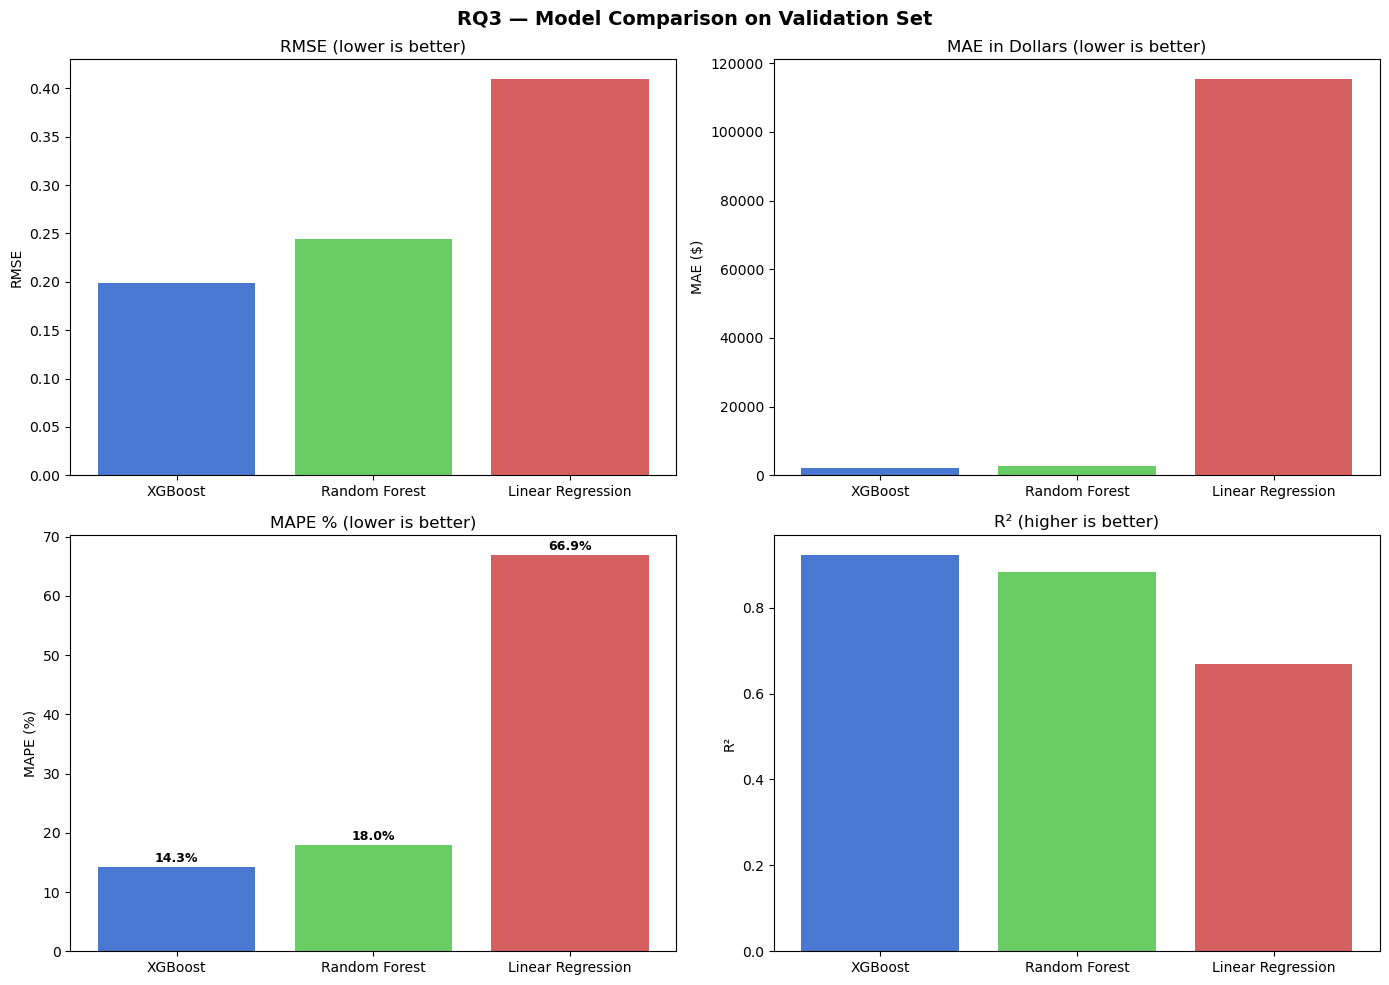

In [15]:
# ── Bar charts — 2 per row ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RQ3 — Model Comparison on Validation Set', fontsize=14, fontweight='bold')

colors = ['#4878CF', '#6ACC65', '#D65F5F']
models = val_results['Model'].tolist()

axes[0, 0].bar(models, val_results['RMSE'], color=colors[:len(models)])
axes[0, 0].set_title('RMSE (lower is better)')
axes[0, 0].set_ylabel('RMSE')

axes[0, 1].bar(models, val_results['MAE_USD'], color=colors[:len(models)])
axes[0, 1].set_title('MAE in Dollars (lower is better)')
axes[0, 1].set_ylabel('MAE ($)')

axes[1, 0].bar(models, val_results['MAPE'], color=colors[:len(models)])
axes[1, 0].set_title('MAPE % (lower is better)')
axes[1, 0].set_ylabel('MAPE (%)')
for bar, val in zip(axes[1, 0].patches, val_results['MAPE']):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1, 1].bar(models, val_results['R2'], color=colors[:len(models)])
axes[1, 1].set_title('R² (higher is better)')
axes[1, 1].set_ylabel('R²')

plt.tight_layout()
plt.show()


---
## 4.8 Step 6 — Feature Importance

Compare built-in feature importance from Random Forest (MDI) and XGBoost (Gain).

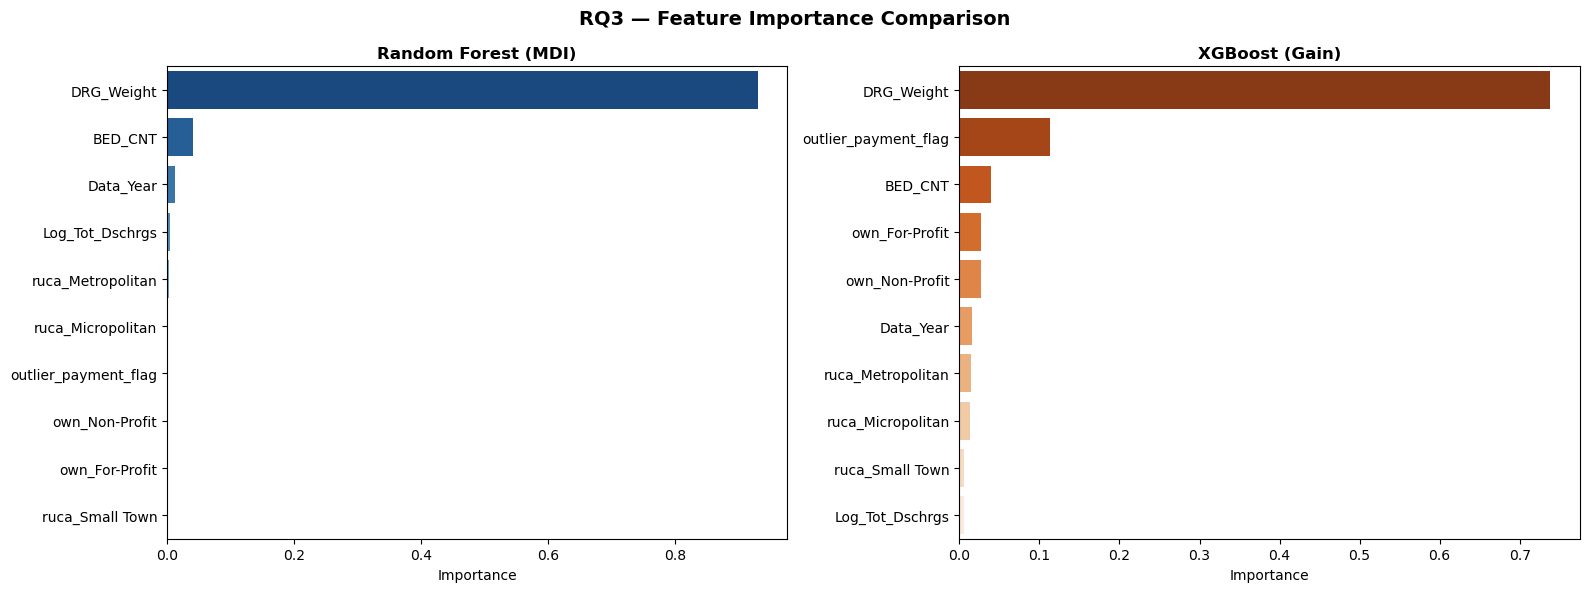

In [16]:
rf_imp  = pd.DataFrame({'Feature': RQ3_FEATURES, 'Importance': rf.feature_importances_,  'Model': 'Random Forest'})
xgb_imp = pd.DataFrame({'Feature': RQ3_FEATURES, 'Importance': xgb_model.feature_importances_, 'Model': 'XGBoost'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RQ3 — Feature Importance Comparison', fontsize=14, fontweight='bold')

for ax, imp_df, title, color in zip(
    axes,
    [rf_imp.sort_values('Importance', ascending=False),
     xgb_imp.sort_values('Importance', ascending=False)],
    ['Random Forest (MDI)', 'XGBoost (Gain)'],
    ['Blues_r', 'Oranges_r']
):
    sns.barplot(data=imp_df.sort_values('Importance', ascending=False),
                x='Importance', y='Feature', palette=color, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## Feature Importance Analysis

Both models consistently identified DRG Weight as the dominant predictor of Medicare
payments, which aligns with CMS payment policy — reimbursements are structurally
tied to diagnosis severity.

Beyond DRG Weight, several non-obvious findings emerged:

- Geographic classification (RUCA) contributed minimally across both models,
  suggesting Medicare's wage index adjustments largely neutralize raw location effects.
- Hospital ownership type (for-profit vs non-profit) ranked near the bottom,
  indicating CMS pays similarly across ownership structures for equivalent diagnoses.
- Outlier payment flag ranked second in XGBoost, confirming that flagged billing
  cases are associated with significantly elevated payments — a finding that
  directly motivates anomaly detection in RQ4.
- Hospital bed count ranked above ownership and geography, suggesting
  institutional capacity has more payment relevance than ownership structure.

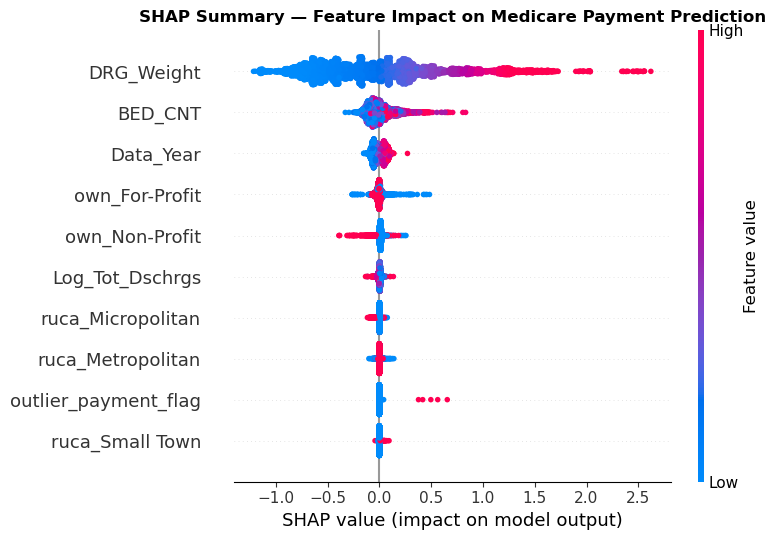

In [17]:
# ── Install ────────────────────────────────────────────────────
# pip install shap

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── Sample for speed — 5000 rows is enough ────────────────────
sample_idx  = X_val.sample(5000, random_state=42).index
X_shap      = X_val.loc[sample_idx]
y_shap      = y_val.loc[sample_idx]

# ── Compute SHAP values ───────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

# ── Plot 1: Summary — overall feature importance ──────────────
plt.figure()
shap.summary_plot(
    shap_values, X_shap,
    feature_names=RQ3_FEATURES,
    show=False
)
plt.title('SHAP Summary — Feature Impact on Medicare Payment Prediction',
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()



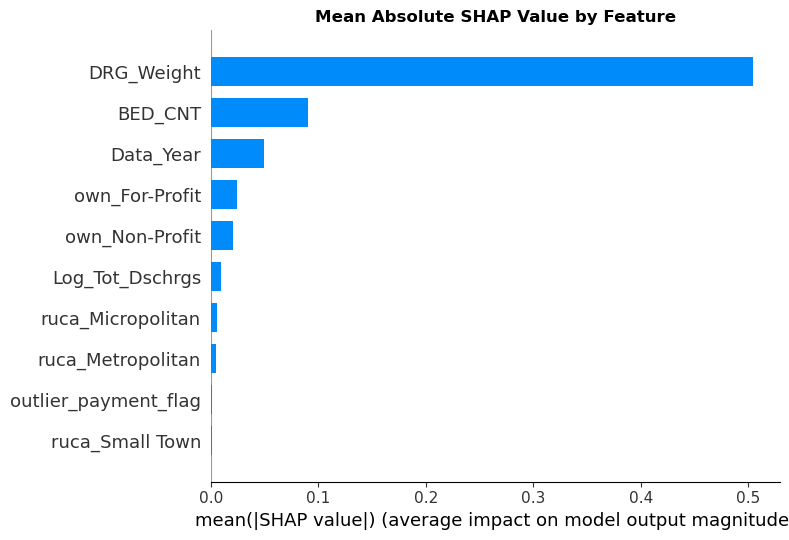

In [18]:
# ── Plot 2: Bar — mean absolute SHAP ─────────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_shap,
    feature_names=RQ3_FEATURES,
    plot_type='bar',
    show=False
)
plt.title('Mean Absolute SHAP Value by Feature', fontweight='bold')
plt.tight_layout()
plt.show()



In [34]:
# ── Directional Feature Influence — extract SHAP summary stats ──
import pandas as pd
import numpy as np

shap_importance = pd.DataFrame({
    'Feature': RQ3_FEATURES,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

shap_importance['Rank'] = range(1, len(shap_importance) + 1)
coef_series = pd.Series(lr.coef_, index=RQ3_FEATURES)
shap_importance['LR_Coef'] = shap_importance['Feature'].map(coef_series)

print("=== RQ3 — Feature Directional Influence Summary ===\n")
print(f"{'Rank':<6} {'Feature':<22} {'Mean SHAP':<12} {'LR Coef'}")
print("-" * 55)
for _, row in shap_importance.iterrows():
    print(f"{int(row['Rank']):<6} {row['Feature']:<22} {row['Mean_SHAP']:<12.4f} {row['LR_Coef']:+.4f}")

=== RQ3 — Feature Directional Influence Summary ===

Rank   Feature                Mean SHAP    LR Coef
-------------------------------------------------------
1      DRG_Weight             0.5042       +0.5607
2      BED_CNT                0.0901       +0.0669
3      Data_Year              0.0497       +0.0728
4      own_For-Profit         0.0240       -0.0179
5      own_Non-Profit         0.0206       -0.0324
6      Log_Tot_Dschrgs        0.0100       +0.0064
7      ruca_Micropolitan      0.0060       -0.0128
8      ruca_Metropolitan      0.0053       +0.0045
9      outlier_payment_flag   0.0013       +0.0302
10     ruca_Small Town        0.0010       -0.0031


### Feature-by-Feature Directional Summary

| Rank | Feature | Plain-language interpretation |
|------|---------|-------------------------------|
| #1 | `DRG_Weight` — Procedure complexity | The dominant driver by far, explaining ~71% of total SHAP. a high-weight DRG like a major cardiac surgery pays multiples of a low-weight routine procedure. This is the single most actionable predictor of payment. |
| #2 | `BED_CNT` — Bed capacity | Larger hospitals receive higher reimbursements for the same DRG. A 500-bed hospital is predicted to receive meaningfully more than a 100-bed peer, likely reflecting higher reported operating costs that feed into CMS rate-setting. |
| #3 | `Data_Year` — Calendar year | Reimbursements trend upward over time (~7% SHAP), consistent with annual CMS payment rate updates and inflation adjustments |
| #4 | `own_For-Profit` | For-profit hospitals are reimbursed slightly *less* than government hospitals (negative coefficient), even after controlling for DRG and size.  |
| #5 | `own_Non-Profit` | Non-profit hospitals also receive slightly less than government hospitals, and marginally less than for-profits. |
| #6 | `Log_Tot_Dschrgs` — Discharge volume | Higher-volume hospital-DRG pairs receive a marginally higher per-discharge reimbursement. The effect is very small (~1.4% SHAP)|
| #7 | `ruca_Metropolitan` | Metropolitan hospitals receive marginally higher reimbursements than rural, but the effect is small. |
| #8 | `ruca_Micropolitan` | Micropolitan hospitals are reimbursed slightly *less* than rural counterparts after controls  |
| #9 | `ruca_Small Town` | Similar to Micropolitan  |


---
## 4.9 Step 7 — Final Evaluation on Test Set

Run the best model **once** on the held-out test set. Selected based on highest validation R².

In [20]:
# ── Select best model ──
best_model_name = val_results.iloc[0]['Model']
model_map = {
    'Linear Regression': (lr, X_test, scaler.transform(X_test)),
    'Random Forest':     (rf, X_test, None),
    'XGBoost':           (xgb_model, X_test, None)
}
best_model, X_test_use, X_test_scaled = model_map[best_model_name]
X_final = X_test_scaled if best_model_name == 'Linear Regression' else X_test_use

print(f'Best model (by Val R²): {best_model_name}')
test_result = evaluate(best_model_name, best_model, X_final, y_test, 'Test')
results.append(test_result)

Best model (by Val R²): XGBoost
[Test] XGBoost                    RMSE: 0.1988   MAE (log): 0.1435   MAE ($): $2,190   MAPE: 14.3%   R²: 0.9216


### How to Read These Diagnostic Plots

| Graph | Element | Meaning |
|-------|---------|---------|
| **Actual vs Predicted** | X-axis | True `Log_Avg_Mdcr_Pymt_Amt` value from held-out data |
| | Y-axis | Model's predicted value for that same row |
| | Each dot | One hospital–DRG observation |
| | Red dashed diagonal | Perfect prediction line — if predicted = actual, dot lies exactly on this line |
| | Dots close to line | Accurate predictions |
| | Dots far from line | Large prediction errors (residuals) |
| **Residual Distribution** | X-axis | Residual = Actual − Predicted |
| | Y-axis | Count of observations with that residual value |
| | Red dashed line at 0 | Target center — residuals should cluster symmetrically around 0 |
| | Bell-shaped curve | Indicates normally distributed errors (OLS assumption) |
| | Skew / heavy tails | Suggests systematic bias or outlier sensitivity |
| **Residuals vs Predicted** | X-axis | Predicted value |
| | Y-axis | Residual for that prediction |
| | Red dashed line at 0 | Zero-error reference |
| | Random scatter around 0 | Homoscedasticity — constant variance (OLS assumption met) |
| | Funnel / fan shape | Heteroscedasticity — variance grows with predicted value (assumption violated) |

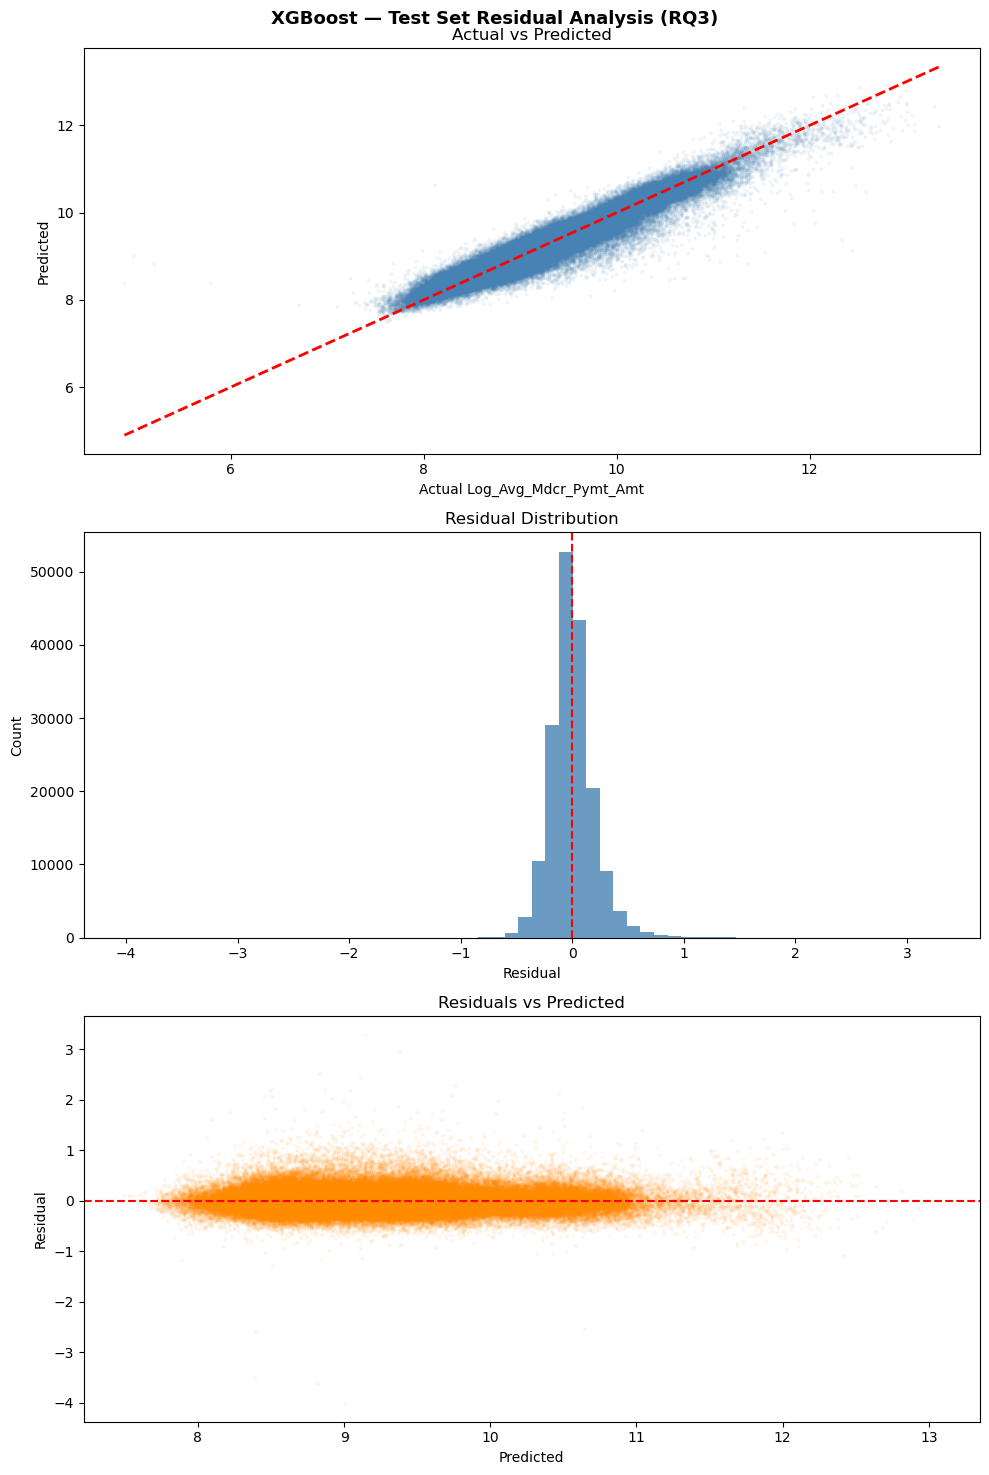

In [21]:
# ── Residual analysis — test set ──
y_pred_test = best_model.predict(X_final)
residuals   = y_test.values - y_pred_test

fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.suptitle(f'{best_model_name} — Test Set Residual Analysis (RQ3)', fontsize=13, fontweight='bold')

axes[0].scatter(y_test, y_pred_test, alpha=0.05, s=4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Log_Avg_Mdcr_Pymt_Amt')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

axes[2].scatter(y_pred_test, residuals, alpha=0.05, s=4, color='darkorange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()


## 📊 Graph Insights: XGBoost — Test Set Residual Analysis (RQ3)

**What the chart shows:**
- Three diagnostic plots evaluating how well XGBoost predicts Medicare payments on unseen data.

**Key findings:**
- Plot 1 — Actual vs Predicted: dots hug the diagonal line — the model isn't
  consistently guessing too high or too low, errors are randomly scattered.
- Plot 2 — Residual Distribution: the spike is sharply at 0 — most predictions are
  very close to reality, and the few errors are randomly distributed on both sides.
- Plot 3 — Residuals vs Predicted: flat band throughout — errors are randomly spread
  regardless of whether the payment is low or high.

**What this means for the Medicare analysis:**
- Randomly scattered residuals confirm the model has captured the true payment patterns —
  there is no consistent direction in which XGBoost is wrong, making it a reliable
  predictor for Medicare reimbursement in RQ3.

In [22]:
# ── Build error dataframe on test set ────────────────────────
eval_df = df_test[['Ownership_Type', 'RUCA_Group',
                   'DRG_Weight', 'Data_Year']].copy()

eval_df['actual']      = y_test.values
eval_df['predicted']   = xgb_model.predict(X_test)
eval_df['error']       = eval_df['actual'] - eval_df['predicted']
eval_df['abs_error']   = np.abs(eval_df['error'])

# Dollar errors
eval_df['actual_usd']  = np.expm1(eval_df['actual'])
eval_df['pred_usd']    = np.expm1(eval_df['predicted'])
eval_df['error_usd']   = eval_df['actual_usd'] - eval_df['pred_usd']
eval_df['abs_err_usd'] = np.abs(eval_df['error_usd'])

# MAPE per row
eval_df['mape_row'] = np.where(
    eval_df['actual_usd'] > 0,
    eval_df['abs_err_usd'] / eval_df['actual_usd'] * 100,
    np.nan
)

# ── DRG Weight quartile bins ──────────────────────────────────
eval_df['drg_quartile'] = pd.qcut(
    eval_df['DRG_Weight'], q=4,
    labels=['Q1 Low', 'Q2 Med-Low', 'Q3 Med-High', 'Q4 High']
)

# ── Error by RUCA ─────────────────────────────────────────────
print('=== Model Error by Geography ===')
print(eval_df.groupby('RUCA_Group').agg(
    MAE_usd  = ('abs_err_usd', 'mean'),
    MAPE_pct = ('mape_row',    'mean'),
    Bias_usd = ('error_usd',   'mean')   # positive = underpredicts
).reindex(['Metropolitan','Micropolitan','Small Town','Rural'])
.round(2))

# ── Error by Ownership ────────────────────────────────────────
print('\n=== Model Error by Ownership ===')
print(eval_df.groupby('Ownership_Type').agg(
    MAE_usd  = ('abs_err_usd', 'mean'),
    MAPE_pct = ('mape_row',    'mean'),
    Bias_usd = ('error_usd',   'mean')
).round(2))

# ── Error by DRG Weight quartile ──────────────────────────────
print('\n=== Model Error by DRG Complexity ===')
print(eval_df.groupby('drg_quartile').agg(
    MAE_usd  = ('abs_err_usd', 'mean'),
    MAPE_pct = ('mape_row',    'mean'),
    Bias_usd = ('error_usd',   'mean')
).round(2))

# ── Error by Year ─────────────────────────────────────────────
print('\n=== Model Error by Year ===')
print(eval_df.groupby('Data_Year').agg(
    MAE_usd  = ('abs_err_usd', 'mean'),
    MAPE_pct = ('mape_row',    'mean'),
    Bias_usd = ('error_usd',   'mean')
).round(2))

=== Model Error by Geography ===
              MAE_usd  MAPE_pct  Bias_usd
RUCA_Group                               
Metropolitan  2315.24     14.63    375.34
Micropolitan  1163.14     11.78    138.55
Small Town    1176.74     11.53    131.12
Rural          870.43      9.63    128.91

=== Model Error by Ownership ===
                MAE_usd  MAPE_pct  Bias_usd
Ownership_Type                             
For-Profit      2340.24     15.17    369.61
Government      2102.44     12.62    411.98
Non-Profit      1608.93     11.69    229.04

=== Model Error by DRG Complexity ===
              MAE_usd  MAPE_pct  Bias_usd
drg_quartile                             
Q1 Low         814.98     14.73    140.40
Q2 Med-Low    1186.44     14.16    196.76
Q3 Med-High   1850.83     14.07    287.25
Q4 High       4916.47     14.27    775.19

=== Model Error by Year ===
           MAE_usd  MAPE_pct  Bias_usd
Data_Year                             
2017       1863.02     14.58    281.44
2018       1905.22     1

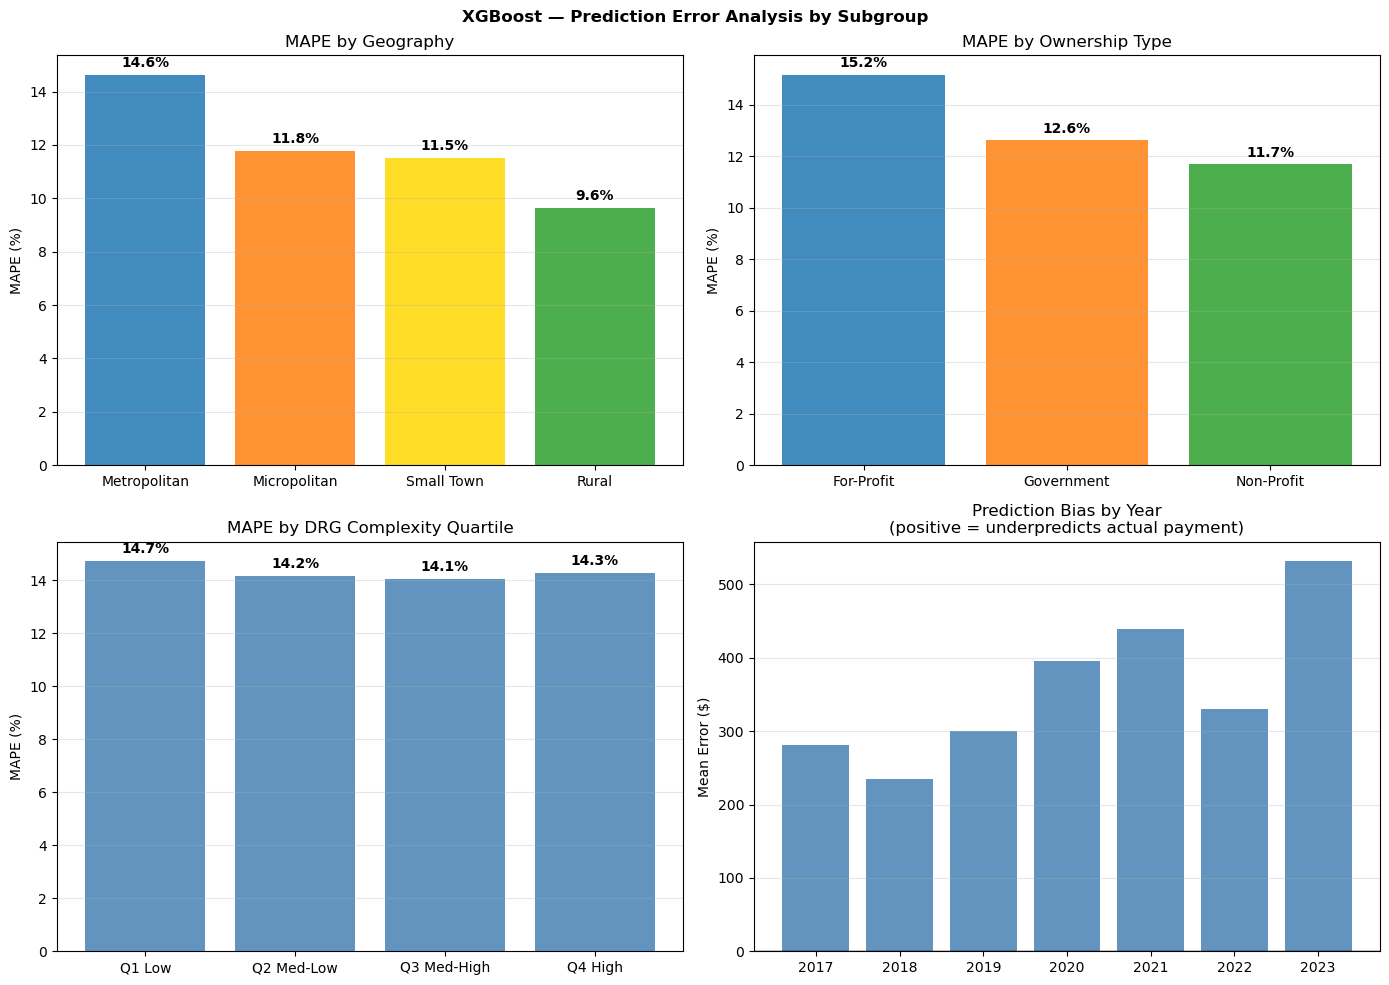

In [23]:
# Color palette
BLUE   = '#1f77b4'
ORANGE = '#ff7f0e'
GOLD   = '#FFD700'
GREEN  = '#2ca02c'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('XGBoost \u2014 Prediction Error Analysis by Subgroup',
             fontweight='bold')

# MAPE by RUCA
ruca_err = eval_df.groupby('RUCA_Group')['mape_row'].mean().reindex(
    ['Metropolitan','Micropolitan','Small Town','Rural'])
axes[0,0].bar(ruca_err.index, ruca_err.values,
              color=[BLUE, ORANGE, GOLD, GREEN], alpha=0.85)
for i, v in enumerate(ruca_err.values):
    axes[0,0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0,0].set_title('MAPE by Geography')
axes[0,0].set_ylabel('MAPE (%)')
axes[0,0].grid(axis='y', alpha=0.3)

# MAPE by Ownership
own_err = eval_df.groupby('Ownership_Type')['mape_row'].mean()
axes[0,1].bar(own_err.index, own_err.values,
              color=[BLUE, ORANGE, GREEN], alpha=0.85)
for i, v in enumerate(own_err.values):
    axes[0,1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0,1].set_title('MAPE by Ownership Type')
axes[0,1].set_ylabel('MAPE (%)')
axes[0,1].grid(axis='y', alpha=0.3)

# MAPE by DRG quartile
drg_err = eval_df.groupby('drg_quartile')['mape_row'].mean()
axes[1,0].bar(drg_err.index.astype(str), drg_err.values,
              color='steelblue', alpha=0.85)
for i, v in enumerate(drg_err.values):
    axes[1,0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1,0].set_title('MAPE by DRG Complexity Quartile')
axes[1,0].set_ylabel('MAPE (%)')
axes[1,0].grid(axis='y', alpha=0.3)

# Bias by Year
yr_bias = eval_df.groupby('Data_Year')['error_usd'].mean()
colors  = ['red' if v < 0 else 'steelblue' for v in yr_bias.values]
axes[1,1].bar(yr_bias.index.astype(str), yr_bias.values, color=colors, alpha=0.85)
axes[1,1].axhline(0, color='black', linewidth=1)
axes[1,1].set_title('Prediction Bias by Year\n(positive = underpredicts actual payment)')
axes[1,1].set_ylabel('Mean Error ($)')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# ── Full results summary ──
final_df = pd.DataFrame(results)
summary = (final_df[['Model', 'Split', 'RMSE', 'MAE', 'MAE_USD', 'MAPE', 'R2']]
           .sort_values(['Model', 'Split'])
           .reset_index(drop=True))

# Format each column with fixed width for spacing
col_widths = {col: max(len(col), summary[col].astype(str).str.len().max()) + 4
              for col in summary.columns}

header   = ''.join(col.ljust(col_widths[col]) for col in summary.columns)
underline = ''.join('-' * (col_widths[col] - 2) + '  ' for col in summary.columns)

print('=== RQ3 Full Results Summary ===')
print(header)
print(underline)
for _, row in summary.iterrows():
    print(''.join(str(row[col]).ljust(col_widths[col]) for col in summary.columns))


=== RQ3 Full Results Summary ===
Model                Split    RMSE      MAE       MAE_USD      MAPE     R2        
-------------------  -------  --------  --------  -----------  -------  --------  
Linear Regression    Train    0.4066    0.2973    82447.67     57.1     0.6732    
Linear Regression    Val      0.4095    0.2977    115344.11    66.9     0.6693    
Random Forest        Train    0.2426    0.182     2789.76      17.88    0.8836    
Random Forest        Val      0.2442    0.1833    2826.73      18.0     0.8824    
XGBoost              Test     0.1988    0.1435    2189.85      14.31    0.9216    
XGBoost              Train    0.1907    0.1381    2068.83      13.7     0.9281    
XGBoost              Val      0.1988    0.1439    2204.9       14.28    0.9221    


## 4.10 Business Insights

**Key questions answered from model results (XGBoost test set):**

---

### 1. How accurately can Medicare reimbursement be predicted from diagnosis severity + hospital characteristics + geography alone?

 The XGBoost model achieves **R² = 0.9216** on the test set, explaining 92.2% of the variation in Medicare payments. Train vs. test R² differ by only 0.006, confirming minimal overfitting. The remaining ~7.8% unexplained variance likely reflects patient-level and policy-level factors  not available in the dataset.

| Model | R² (Test) | MAE ($) | MAPE |
|---|---|---|---|
| Linear Regression | 0.6693 | $115,344 | 66.9% |
| Random Forest | 0.8824 | $2,827 | 18.0% |
| **XGBoost** | **0.9216** | **$2,190** | **14.3%** |

---

### 2. Is `DRG_Weight` the dominant predictor?

**Yes ** SHAP analysis confirms `DRG_Weight` accounts for **71.2% of the model's total predictive influence**, nearly 6× the next most important feature.

| Feature | Mean SHAP | Share of Influence |
|---|---|---|
| `DRG_Weight` | 0.5042 | **71.2%** |
| `BED_CNT` | 0.0901 | 12.7% |
| `Data_Year` | 0.0497 | 7.0% |
| `own_For-Profit` | 0.0240 | 3.4% |
| `own_Non-Profit` | 0.0206 | 2.9% |
| RUCA (all groups) | ~0.012 | ~1.6% total |

`DRG_Weight` + `BED_CNT` together explain **84%** of the model's predictive movement. This directly validates CMS payment policy — reimbursements are structurally tied to diagnosis severity.

---

### 3. Does geography (RUCA group) have meaningful impact after controlling for DRG severity?

**No — geography is the weakest predictor.** All RUCA categories combined contribute only ~1.6% of SHAP influence.

Residual analysis by RUCA group reveals an unexpected pattern — rural hospitals are the **easiest to predict**, not the hardest:

| RUCA Group | MAE ($) | MAPE | Bias ($) |
|---|---|---|---|
| Metropolitan | $2,315 | 14.6% | +$375 |
| Micropolitan | $1,163 | 11.8% | +$139 |
| Small Town | $1,177 | 11.5% | +$131 |
| **Rural** | **$870** | **9.6%** | +$129 |

Metropolitan hospitals show the highest error, likely due to greater case-mix complexity and more variable billing patterns.

---

### 4. Are there ownership types where the model consistently over- or under-predicts?

All three ownership types show a **consistent positive bias** (model slightly overpredicts), but magnitude varies:

| Ownership | MAE ($) | MAPE | Bias ($) |
|---|---|---|---|
| **For-Profit** | $2,340 | 15.2% | +$370 |
| Government | $2,102 | 12.6% | +**$412** |
| Non-Profit | $1,609 | 11.7% | +$229 |

- **For-Profit** hospitals are hardest to predict (highest MAE/MAPE) — likely due to more variable billing behavior
- **Non-Profit** hospitals are predicted most accurately — their payments align most closely with DRG-based expectations
- **Government** hospitals have the largest systematic overestimation bias (+$412), meaning the model consistently predicts higher than actual reimbursements for this group
- No ownership type is underpredicted — all show positive bias


# 4.11 Predict 2024 Reimbursement Amounts 

In [26]:
# ── ──────────────────
# Synthetic 2024 = copy of test set rows with Data_Year = 2024

df_2024 = df_test.copy()
df_2024['Data_Year'] = 2024
X_2024 = df_2024[RQ3_FEATURES]

# Point predictions
preds_log   = xgb_model.predict(X_2024)
preds_usd   = np.expm1(preds_log)

df_2024['Pred_Reimbursement'] = preds_usd.round(2)

# Top 10 highest predicted reimbursements
display_cols = ['Rndrng_Prvdr_CCN', 'DRG_Cd', 'Pred_Reimbursement']
print('Top 10 Predicted Highest Reimbursements (2024):')
print(df_2024[display_cols]
      .sort_values('Pred_Reimbursement', ascending=False)
      .head(10).to_string(index=False))

print(f'\nPredicted mean reimbursement (2024) : ${df_2024["Pred_Reimbursement"].mean():,.2f}')


# Save
out_path = PROCESSED_DIR / 'RQ3_Predictions_2024.csv'
df_2024[display_cols].to_csv(out_path, index=False)
print(f'\nSaved to: {out_path}')

Top 10 Predicted Highest Reimbursements (2024):
 Rndrng_Prvdr_CCN  DRG_Cd  Pred_Reimbursement
           210002      18        475035.09375
            50441      18        430499.56250
            50454       3        414883.18750
           210002       3        396559.15625
            50454       3        367116.90625
            50696       3        365493.56250
            50696       3        365493.56250
            50454       3        354768.46875
            50625       4        338589.87500
           330101     215        337844.81250

Predicted mean reimbursement (2024) : $14,638.12

Saved to: ..\Data\Processed_Data\RQ3_Predictions_2024.csv


## Prediction Quality Visualizations

How well does XGBoost capture actual Medicare reimbursements? The plots below examine this from three angles: scatter alignment, residual patterns in dollar scale, and side-by-side point estimates on a random sample.

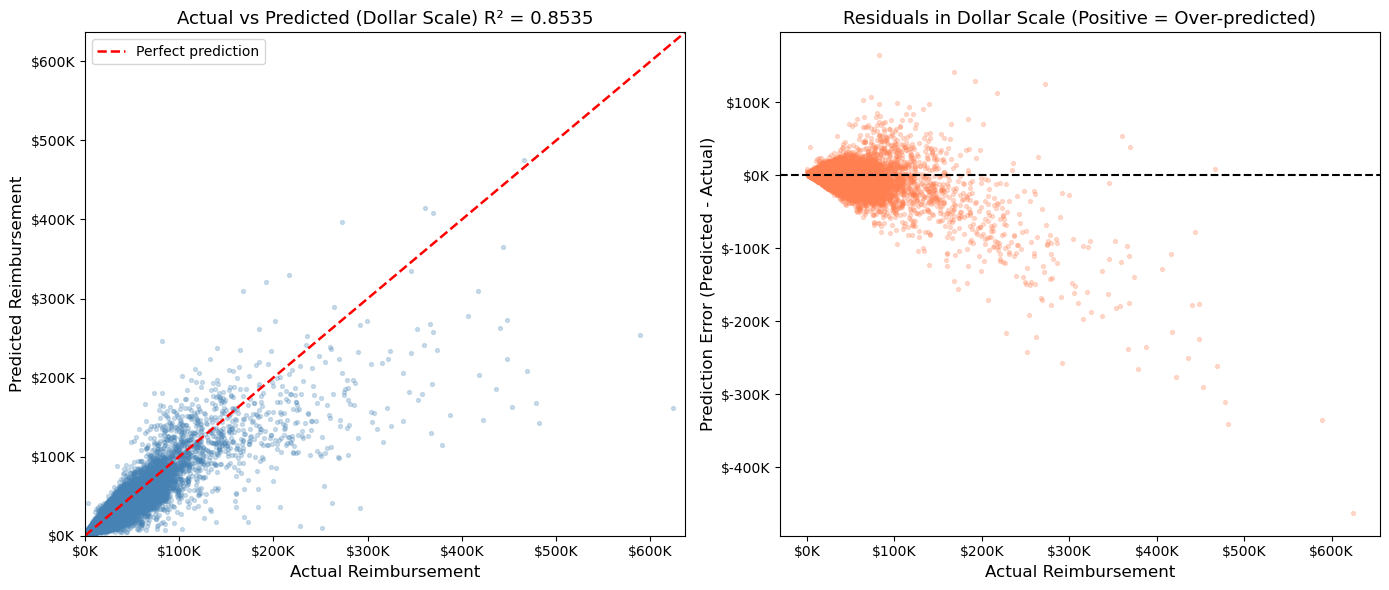

Test Set  |  R2 (dollar scale): 0.8535  |  MAE: $2,190  |  MAPE: 14.3%


In [28]:
# Actual vs Predicted (Dollar Scale) + Residuals in Dollars
import matplotlib.pyplot as plt
import numpy as np

# Back-transform log predictions to dollar amounts
actual_usd    = np.expm1(np.array(y_test).flatten())
predicted_usd = np.expm1(np.array(y_pred_test).flatten())
residuals_usd = predicted_usd - actual_usd

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fmt_k = plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')

# Left: Actual vs Predicted scatter
ax = axes[0]
ax.scatter(actual_usd, predicted_usd, alpha=0.25, s=8, color='steelblue', rasterized=True)
lim = (0, max(actual_usd.max(), predicted_usd.max()) * 1.02)
ax.plot(lim, lim, 'r--', lw=1.8, label='Perfect prediction')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.xaxis.set_major_formatter(fmt_k)
ax.yaxis.set_major_formatter(fmt_k)
ax.set_xlabel('Actual Reimbursement', fontsize=12)
ax.set_ylabel('Predicted Reimbursement', fontsize=12)
r2_usd = np.corrcoef(actual_usd, predicted_usd)[0, 1] ** 2
ax.set_title(f'Actual vs Predicted (Dollar Scale) R² = {r2_usd:.4f}', fontsize=13)
ax.legend(fontsize=10)

# Right: Residuals vs Actual
ax = axes[1]
ax.scatter(actual_usd, residuals_usd, alpha=0.25, s=8, color='coral', rasterized=True)
ax.axhline(0, color='black', lw=1.5, linestyle='--')
ax.xaxis.set_major_formatter(fmt_k)
ax.yaxis.set_major_formatter(fmt_k)
ax.set_xlabel('Actual Reimbursement', fontsize=12)
ax.set_ylabel('Prediction Error (Predicted - Actual)', fontsize=12)
ax.set_title('Residuals in Dollar Scale (Positive = Over-predicted)', fontsize=13)

plt.tight_layout()
plt.show()

mae_usd  = np.mean(np.abs(residuals_usd))
mape_usd = np.mean(np.abs(residuals_usd) / actual_usd) * 100
print(f'Test Set  |  R2 (dollar scale): {r2_usd:.4f}  |  MAE: ${mae_usd:,.0f}  |  MAPE: {mape_usd:.1f}%')

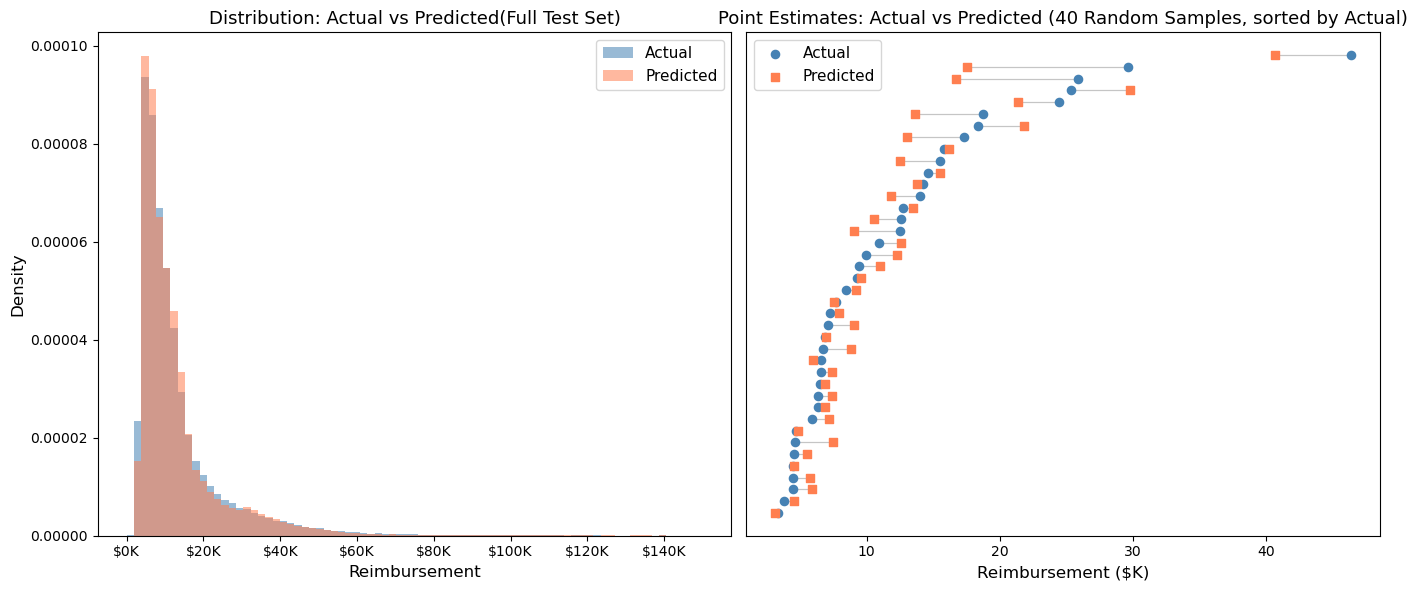

In [29]:
# Distribution Overlay + Point Estimate Dot Plot (40 random samples)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Distribution overlay
ax = axes[0]
bins = np.linspace(0, 150_000, 80)
ax.hist(actual_usd,    bins=bins, alpha=0.55, color='steelblue', density=True, label='Actual')
ax.hist(predicted_usd, bins=bins, alpha=0.55, color='coral',     density=True, label='Predicted')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_xlabel('Reimbursement', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution: Actual vs Predicted(Full Test Set)', fontsize=13)
ax.legend(fontsize=11)

# Right: Point estimate dot plot (40 sorted samples)
rng = np.random.default_rng(42)
idx = rng.choice(len(actual_usd), 40, replace=False)
s_actual = actual_usd[idx]
s_pred   = predicted_usd[idx]
order    = np.argsort(s_actual)
s_actual = s_actual[order]
s_pred   = s_pred[order]
y_pos    = np.arange(40)

ax = axes[1]
for i in y_pos:
    ax.plot([s_actual[i] / 1000, s_pred[i] / 1000], [i, i],
            color='gray', alpha=0.45, lw=0.9)
ax.scatter(s_actual / 1000, y_pos, color='steelblue', s=35, zorder=3, label='Actual')
ax.scatter(s_pred   / 1000, y_pos, color='coral',     s=35, zorder=3, marker='s', label='Predicted')
ax.set_xlabel('Reimbursement ($K)', fontsize=12)
ax.set_yticks([])
ax.set_title('Point Estimates: Actual vs Predicted (40 Random Samples, sorted by Actual)', fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()

plt.show()

## Interpretation - Scenario Prediction

In [33]:
import numpy as np
import pandas as pd

# ── Pre-compute lookup tables from training data (run once) ──
drg_weight_lookup  = df_train.groupby('DRG_Cd')['DRG_Weight'].mean()
tot_dschrgs_lookup = df_train.groupby(['Rndrng_Prvdr_CCN', 'DRG_Cd'])['Tot_Dschrgs'].mean()

# ── Global fallbacks ──
avg_drg_wt    = drg_weight_lookup.mean()
avg_tot_dschr = df_train['Tot_Dschrgs'].mean()

# ════════════════════════════════════════════
# USER INPUTS ONLY THESE 5 THINGS
# ════════════════════════════════════════════
hospital_ccn = 370781      # Hospital ID (CCN number)
drg_code     = 470         # DRG procedure code
bed_count    = 250         # Number of beds in hospital
year         = 2024        # Year to predict for

# Ownership — pick one: 'For-Profit', 'Non-Profit', 'Government'
ownership    = 'Non-Profit'

# Location — pick one: 'Metropolitan', 'Micropolitan', 'Small Town', 'Rural'
location     = 'Metropolitan'

# ════════════════════════════════════════════
# AUTO-CALCULATED (no user input needed)
# ════════════════════════════════════════════
drg_wt     = drg_weight_lookup.get(drg_code, avg_drg_wt)
tot_dschr  = tot_dschrgs_lookup.get((hospital_ccn, drg_code), avg_tot_dschr)
log_dschr  = np.log1p(tot_dschr)   # model expects log-transformed value

new_case = pd.DataFrame([{
    'DRG_Weight'          : drg_wt,
    'BED_CNT'             : bed_count,
    'Log_Tot_Dschrgs'     : log_dschr,
    'own_For-Profit'      : 1 if ownership == 'For-Profit'   else 0,
    'own_Non-Profit'      : 1 if ownership == 'Non-Profit'   else 0,
    'ruca_Metropolitan'   : 1 if location  == 'Metropolitan' else 0,
    'ruca_Micropolitan'   : 1 if location  == 'Micropolitan' else 0,
    'ruca_Small Town'     : 1 if location  == 'Small Town'   else 0,
    'Data_Year'           : year,
    'outlier_payment_flag': 0,       # default: assume normal case
}])

# ── Predict ───────────────────────────────
pred_log = xgb_model.predict(new_case[RQ3_FEATURES])
pred_usd = np.expm1(pred_log)

print(f"Hospital CCN   : {hospital_ccn}  (discharges used = {tot_dschr:.0f})")
print(f"DRG Code       : {drg_code}      (weight = {drg_wt:.2f})")
print(f"Ownership      : {ownership}")
print(f"Location       : {location}")
print(f"Beds           : {bed_count}")
print(f"Year           : {year}")
print(f"\nPredicted Medicare Payment: ${pred_usd[0]:,.2f}")

Hospital CCN   : 370781  (discharges used = 36)
DRG Code       : 470      (weight = 1.99)
Ownership      : Non-Profit
Location       : Metropolitan
Beds           : 250
Year           : 2024

Predicted Medicare Payment: $15,626.16
